# TMDB Movie Profitability Evaluation Pipeline

**Author:** Logan  
**Date:** February 2026  
**Track:** C - Alternate Target Definition  

## Target Definition

**Profitable Movie Classification**

This pipeline predicts **financial profitability**:

```python
ROI = revenue / budget
profitable = 1 if ROI >= 2.5 else 0
```

## Section 1: Data Loading and Preprocessing

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
FIGURES = Path('reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

print("Environment ready")

Environment ready


In [2]:
# Load data
df = pd.read_csv('TMDB/movies_metadata.csv', low_memory=False)
print(f"Raw data: {df.shape}")
df.head()

Raw data: (45466, 24)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [3]:
# Quick preprocessing
# Convert numeric columns
numeric_cols = ['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'vote_count']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filter for valid movies
df = df[
    (df['budget'] > 100000) &      # Real budgets only
    (df['revenue'] > 0) &          # Has revenue data
    (df['runtime'] > 60) &         # Feature length
    (df['vote_count'] >= 50)       # Sufficient votes
].copy()

print(f"\nAfter filtering: {df.shape}")
print(f"Removed {len(pd.read_csv('TMDB/movies_metadata.csv', low_memory=False)) - len(df):,} invalid movies")


After filtering: (4328, 24)
Removed 41,138 invalid movies


## Section 2: Target Definition and Class Balance Analysis

In [4]:
# Define profitability target
df['roi'] = df['revenue'] / (df['budget'] + 1)
df['profitable'] = (df['roi'] >= 2.5).astype(int)

print("Target Definition: Profitable Movie")
print("  Formula: ROI = revenue / budget")
print("  Threshold: ROI >= 2.5x")
print("  Rationale: Accounts for marketing costs (≈ production budget)")
print()
print("ROI Distribution:")
print(df['roi'].describe())
print()
print("Class Balance:")
print(df['profitable'].value_counts())
print()
print("Class Proportions:")
print(df['profitable'].value_counts(normalize=True))

Target Definition: Profitable Movie
  Formula: ROI = revenue / budget
  Threshold: ROI >= 2.5x
  Rationale: Accounts for marketing costs (≈ production budget)

ROI Distribution:
count    4.328000e+03
mean     5.038944e+00
std      1.727341e+01
min      5.217391e-07
25%      9.882172e-01
50%      2.273502e+00
75%      4.422005e+00
max      6.538411e+02
Name: roi, dtype: float64

Class Balance:
profitable
0    2329
1    1999
Name: count, dtype: int64

Class Proportions:
profitable
0    0.538124
1    0.461876
Name: proportion, dtype: float64


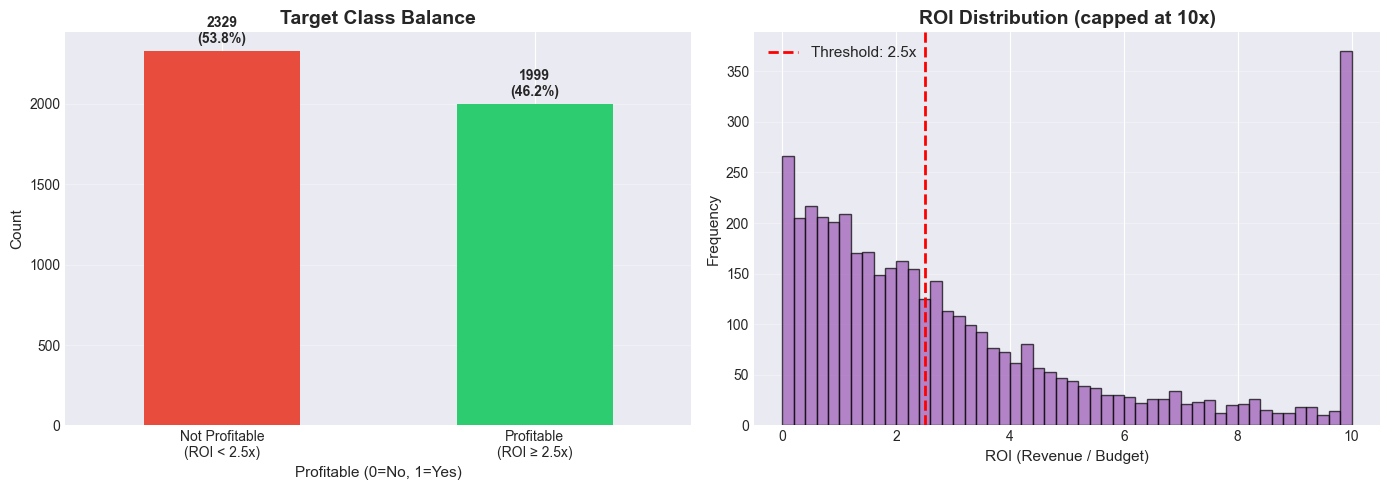

In [5]:
# EDA Plot 1: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class balance
df['profitable'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Target Class Balance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Profitable (0=No, 1=Yes)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xticklabels(['Not Profitable\n(ROI < 2.5x)', 'Profitable\n(ROI ≥ 2.5x)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Add percentages
for i, v in enumerate(df['profitable'].value_counts()):
    pct = v / len(df) * 100
    axes[0].text(i, v + 50, f'{v}\n({pct:.1f}%)', ha='center', fontweight='bold')

# ROI distribution
axes[1].hist(df['roi'].clip(upper=10), bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1].axvline(2.5, color='red', linestyle='--', linewidth=2, label='Threshold: 2.5x')
axes[1].set_title('ROI Distribution (capped at 10x)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ROI (Revenue / Budget)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / '01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 3: Feature Engineering and EDA

In [6]:
# Extract basic pre-release features
import json

def safe_json_loads(s):
    if pd.isna(s):
        return []
    try:
        return json.loads(s.replace("'", '"'))
    except:
        return []

# Genre features
df['genres_list'] = df['genres'].apply(lambda x: [g['name'] for g in safe_json_loads(x) if 'name' in g])
df['genre_count'] = df['genres_list'].apply(len)
df['is_action'] = df['genres_list'].apply(lambda x: int('Action' in x))
df['is_comedy'] = df['genres_list'].apply(lambda x: int('Comedy' in x))
df['is_drama'] = df['genres_list'].apply(lambda x: int('Drama' in x))

# Production features
df['companies_list'] = df['production_companies'].apply(lambda x: [c['name'] for c in safe_json_loads(x) if 'name' in c])
df['num_production_companies'] = df['companies_list'].apply(len)

# Franchise
df['is_franchise'] = df['belongs_to_collection'].notna().astype(int)

# Temporal
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date'])
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['is_summer_release'] = df['release_month'].isin([5, 6, 7, 8]).astype(int)
df['is_holiday_release'] = df['release_month'].isin([11, 12]).astype(int)

# Budget tier
df['budget_millions'] = df['budget'] / 1_000_000

print(f"Dataset with features: {df.shape}")
print("\nFeatures created:")
print("  - Genre: genre_count, is_action, is_comedy, is_drama")
print("  - Production: num_production_companies")
print("  - Franchise: is_franchise")
print("  - Temporal: release_month, is_summer_release, is_holiday_release")
print("  - Budget: budget_millions")

Dataset with features: (4328, 39)

Features created:
  - Genre: genre_count, is_action, is_comedy, is_drama
  - Production: num_production_companies
  - Franchise: is_franchise
  - Temporal: release_month, is_summer_release, is_holiday_release
  - Budget: budget_millions


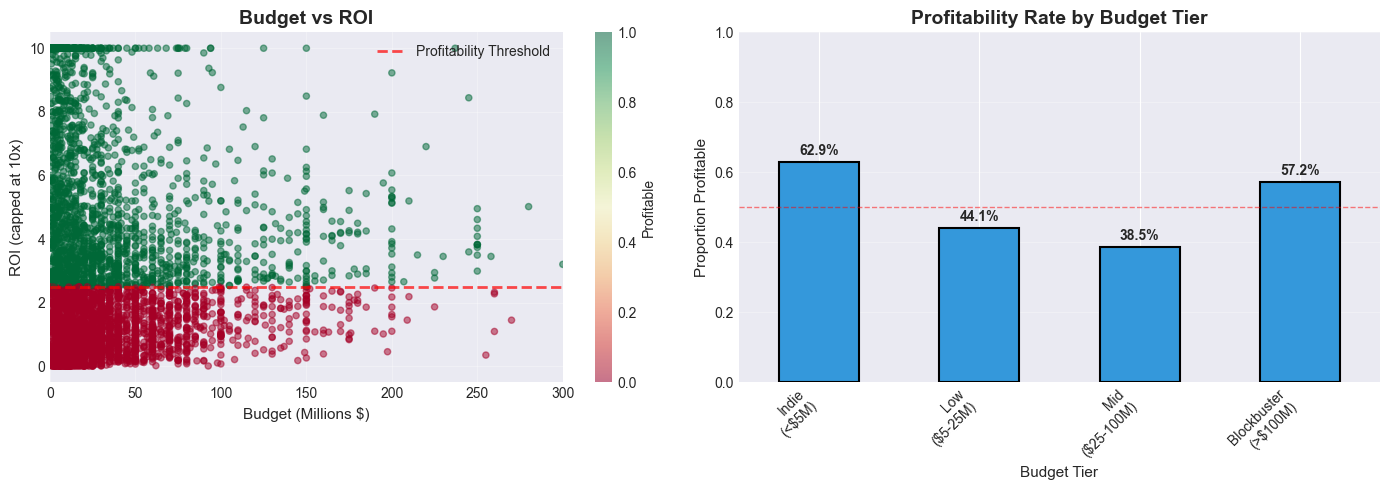

In [7]:
# EDA Plot 2: Budget vs ROI and Profitability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Budget vs ROI scatter
scatter = axes[0].scatter(
    df['budget_millions'], 
    df['roi'].clip(upper=10),
    c=df['profitable'],
    cmap='RdYlGn',
    alpha=0.5,
    s=20
)
axes[0].axhline(2.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Profitability Threshold')
axes[0].set_xlabel('Budget (Millions $)', fontsize=11)
axes[0].set_ylabel('ROI (capped at 10x)', fontsize=11)
axes[0].set_title('Budget vs ROI', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 300])
axes[0].legend()
axes[0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Profitable')

# Profitability by budget tier
df['budget_tier'] = pd.cut(
    df['budget'], 
    bins=[0, 5e6, 25e6, 100e6, np.inf],
    labels=['Indie\n(<$5M)', 'Low\n($5-25M)', 'Mid\n($25-100M)', 'Blockbuster\n(>$100M)']
)
profit_by_tier = df.groupby('budget_tier', observed=True)['profitable'].mean()
profit_by_tier.plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Budget Tier', fontsize=11)
axes[1].set_ylabel('Proportion Profitable', fontsize=11)
axes[1].set_title('Profitability Rate by Budget Tier', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

# Add percentage labels
for i, v in enumerate(profit_by_tier):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / '02_budget_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

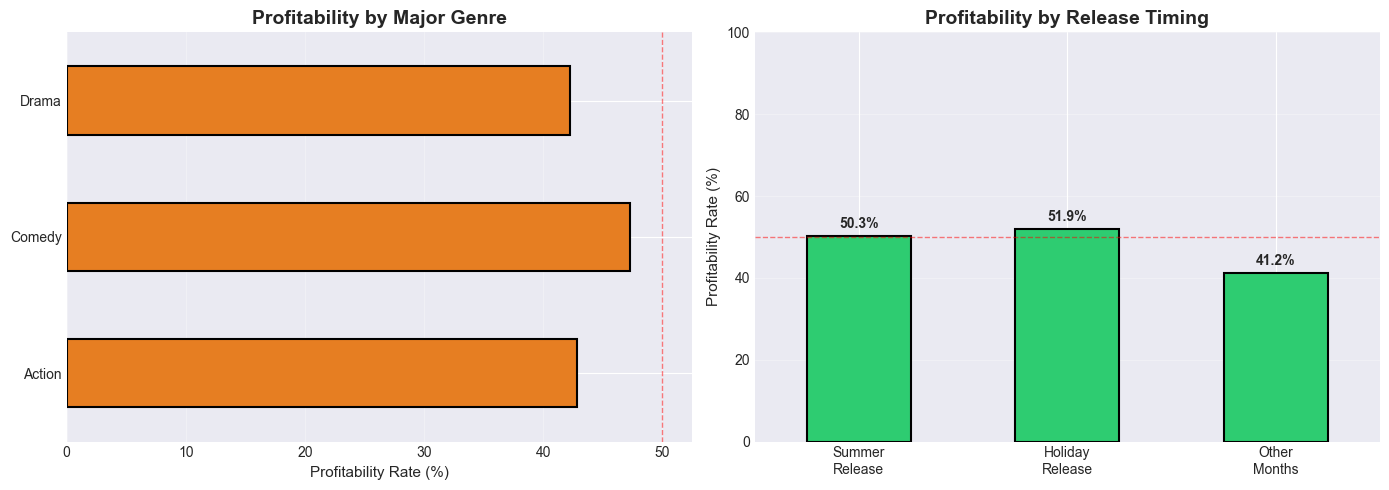

In [8]:
# EDA Plot 3: Genre and Release Timing Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profitability by genre
genre_profit = pd.DataFrame({
    'Action': df['is_action'].sum(),
    'Comedy': df['is_comedy'].sum(),
    'Drama': df['is_drama'].sum()
}, index=['Count']).T

genre_profit['Profitable %'] = [
    df[df['is_action'] == 1]['profitable'].mean() * 100,
    df[df['is_comedy'] == 1]['profitable'].mean() * 100,
    df[df['is_drama'] == 1]['profitable'].mean() * 100
]

genre_profit['Profitable %'].plot(kind='barh', ax=axes[0], color='#e67e22', edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Profitability Rate (%)', fontsize=11)
axes[0].set_title('Profitability by Major Genre', fontsize=14, fontweight='bold')
axes[0].axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].grid(axis='x', alpha=0.3)

# Profitability by release timing
timing_data = pd.DataFrame({
    'Summer\nRelease': [df[df['is_summer_release'] == 1]['profitable'].mean() * 100],
    'Holiday\nRelease': [df[df['is_holiday_release'] == 1]['profitable'].mean() * 100],
    'Other\nMonths': [df[(df['is_summer_release'] == 0) & (df['is_holiday_release'] == 0)]['profitable'].mean() * 100]
}).T

timing_data[0].plot(kind='bar', ax=axes[1], color='#2ecc71', edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Profitability Rate (%)', fontsize=11)
axes[1].set_title('Profitability by Release Timing', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 100])

# Add value labels
for i, v in enumerate(timing_data[0]):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / '03_genre_timing_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

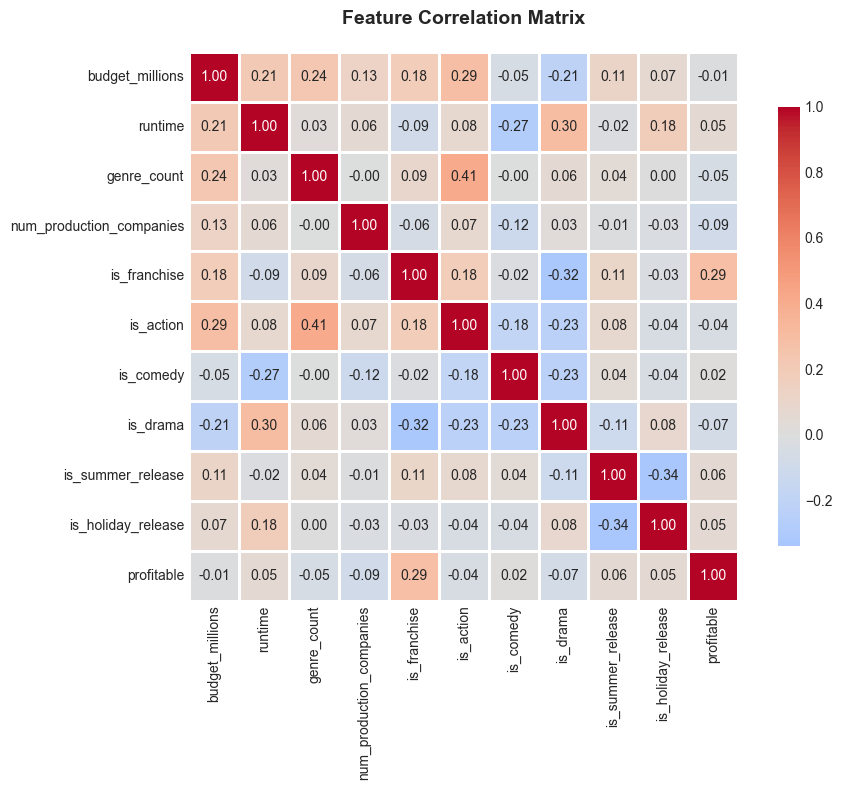


Key correlations with profitability:
profitable                  1.000000
is_franchise                0.286921
is_summer_release           0.057932
runtime                     0.054765
is_holiday_release          0.054440
is_comedy                   0.015807
budget_millions            -0.009564
is_action                  -0.041573
genre_count                -0.052653
is_drama                   -0.072845
num_production_companies   -0.087855
Name: profitable, dtype: float64


In [9]:
# EDA Plot 4: Feature Correlation Heatmap
feature_cols = [
    'budget_millions', 'runtime', 'genre_count', 'num_production_companies',
    'is_franchise', 'is_action', 'is_comedy', 'is_drama',
    'is_summer_release', 'is_holiday_release', 'profitable'
]

plt.figure(figsize=(10, 8))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FIGURES / '04_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey correlations with profitability:")
print(corr_matrix['profitable'].sort_values(ascending=False))

## Section 4: Model Training - Baseline Models

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

# Select features (pre-release only)
features = [
    'budget_millions', 'runtime', 'genre_count', 'num_production_companies',
    'is_franchise', 'is_action', 'is_comedy', 'is_drama',
    'is_summer_release', 'is_holiday_release'
]

# Prepare data
X = df[features].fillna(df[features].median())
y = df['profitable']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nFeatures: {features}")

Training set: (3246, 10)
Test set: (1082, 10)

Features: ['budget_millions', 'runtime', 'genre_count', 'num_production_companies', 'is_franchise', 'is_action', 'is_comedy', 'is_drama', 'is_summer_release', 'is_holiday_release']


In [11]:
# Model 1: SVM Classifier
print("Training SVM Classifier...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, svm_prob):.4f}")

Training SVM Classifier...

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.75      0.68       582
           1       0.62      0.48      0.55       500

    accuracy                           0.63      1082
   macro avg       0.63      0.62      0.61      1082
weighted avg       0.63      0.63      0.62      1082

ROC-AUC Score: 0.6720


In [12]:
# Model 2: Gradient Boosting Classifier
print("Training Gradient Boosting Classifier...")
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(X_train_scaled, y_train)

gb_pred = gb_model.predict(X_test_scaled)
gb_prob = gb_model.predict_proba(X_test_scaled)[:, 1]

print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, gb_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, gb_prob):.4f}")

Training Gradient Boosting Classifier...

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.76      0.70       582
           1       0.66      0.54      0.59       500

    accuracy                           0.66      1082
   macro avg       0.66      0.65      0.65      1082
weighted avg       0.66      0.66      0.65      1082

ROC-AUC Score: 0.6940


## Section 5: Cross-Validation and Model Stability

In [13]:
from sklearn.model_selection import cross_validate

# Cross-validation for both models
cv_scoring = ['roc_auc', 'f1', 'accuracy']

print("Running 5-fold cross-validation...\n")

# SVM CV
svm_cv_scores = cross_validate(
    svm_model, X_train_scaled, y_train, 
    cv=5, scoring=cv_scoring, n_jobs=-1
)

print("SVM Cross-Validation Results:")
print(f"  ROC-AUC: {svm_cv_scores['test_roc_auc'].mean():.4f} (+/- {svm_cv_scores['test_roc_auc'].std():.4f})")
print(f"  F1-Score: {svm_cv_scores['test_f1'].mean():.4f} (+/- {svm_cv_scores['test_f1'].std():.4f})")
print(f"  Accuracy: {svm_cv_scores['test_accuracy'].mean():.4f} (+/- {svm_cv_scores['test_accuracy'].std():.4f})")

# GB CV
gb_cv_scores = cross_validate(
    gb_model, X_train_scaled, y_train, 
    cv=5, scoring=cv_scoring, n_jobs=-1
)

print("\nGradient Boosting Cross-Validation Results:")
print(f"  ROC-AUC: {gb_cv_scores['test_roc_auc'].mean():.4f} (+/- {gb_cv_scores['test_roc_auc'].std():.4f})")
print(f"  F1-Score: {gb_cv_scores['test_f1'].mean():.4f} (+/- {gb_cv_scores['test_f1'].std():.4f})")
print(f"  Accuracy: {gb_cv_scores['test_accuracy'].mean():.4f} (+/- {gb_cv_scores['test_accuracy'].std():.4f})")

# Calculate stability (coefficient of variation)
print("\nModel Stability (Coefficient of Variation):")
print(f"  SVM ROC-AUC CV: {(svm_cv_scores['test_roc_auc'].std() / svm_cv_scores['test_roc_auc'].mean()):.4f}")
print(f"  GB ROC-AUC CV: {(gb_cv_scores['test_roc_auc'].std() / gb_cv_scores['test_roc_auc'].mean()):.4f}")
print("  (Lower = more stable)")

Running 5-fold cross-validation...

SVM Cross-Validation Results:
  ROC-AUC: 0.6940 (+/- 0.0220)
  F1-Score: 0.5855 (+/- 0.0168)
  Accuracy: 0.6497 (+/- 0.0172)

Gradient Boosting Cross-Validation Results:
  ROC-AUC: 0.6929 (+/- 0.0183)
  F1-Score: 0.5899 (+/- 0.0223)
  Accuracy: 0.6543 (+/- 0.0198)

Model Stability (Coefficient of Variation):
  SVM ROC-AUC CV: 0.0316
  GB ROC-AUC CV: 0.0264
  (Lower = more stable)


## Section 6: ROC Curve Analysis

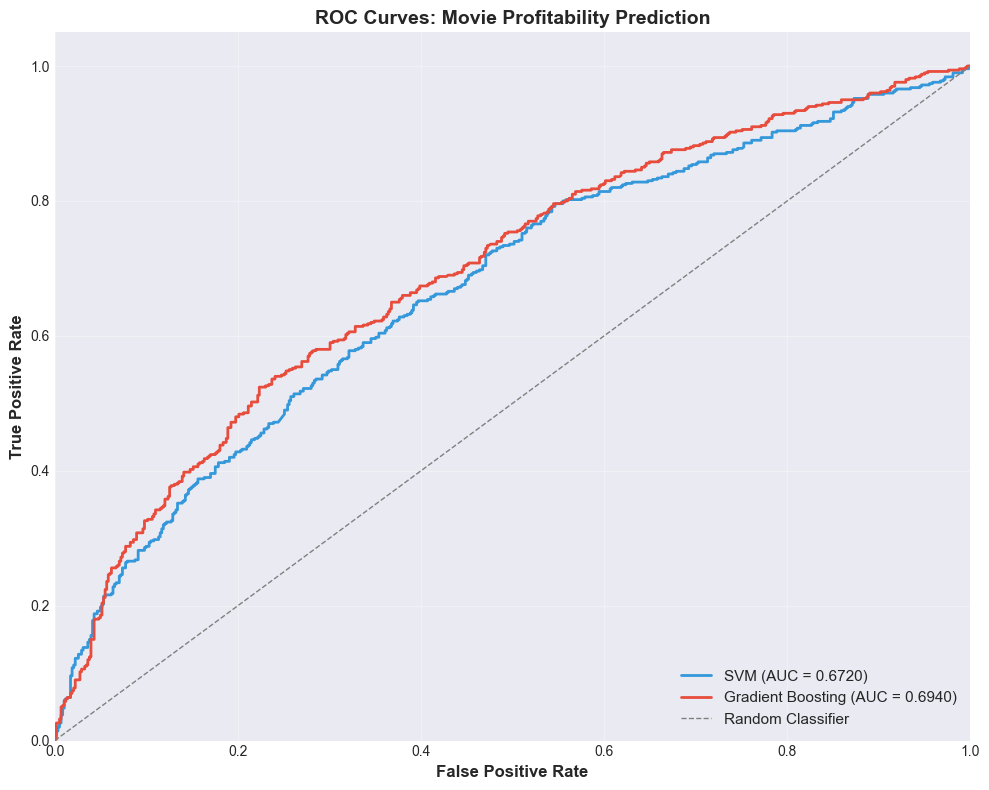

In [14]:
# Generate ROC curves
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)
svm_auc = auc(svm_fpr, svm_tpr)

gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)
gb_auc = auc(gb_fpr, gb_tpr)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(svm_fpr, svm_tpr, color='#3498db', lw=2, label=f'SVM (AUC = {svm_auc:.4f})')
plt.plot(gb_fpr, gb_tpr, color='#e74c3c', lw=2, label=f'Gradient Boosting (AUC = {gb_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves: Movie Profitability Prediction', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '05_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 7: Results Summary

In [15]:
# Summary
summary = {
    'dataset_size': len(df),
    'target': 'profitable (ROI >= 2.5x)',
    'class_balance': {
        'not_profitable': int((y == 0).sum()),
        'profitable': int((y == 1).sum())
    },
    'features': features,
    'models': {
        'SVM': {
            'test_roc_auc': float(roc_auc_score(y_test, svm_prob)),
            'cv_roc_auc_mean': float(svm_cv_scores['test_roc_auc'].mean()),
            'cv_roc_auc_std': float(svm_cv_scores['test_roc_auc'].std())
        },
        'GradientBoosting': {
            'test_roc_auc': float(roc_auc_score(y_test, gb_prob)),
            'cv_roc_auc_mean': float(gb_cv_scores['test_roc_auc'].mean()),
            'cv_roc_auc_std': float(gb_cv_scores['test_roc_auc'].std())
        }
    }
}

import json
with open('reports/evaluation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nDataset: {summary['dataset_size']:,} movies")
print(f"Target: {summary['target']}")
print(f"\nClass Balance:")
print(f"  Not Profitable: {summary['class_balance']['not_profitable']:,}")
print(f"  Profitable: {summary['class_balance']['profitable']:,}")
print(f"\nModel Performance (Test Set):")
print(f"  SVM ROC-AUC: {summary['models']['SVM']['test_roc_auc']:.4f}")
print(f"  GB ROC-AUC: {summary['models']['GradientBoosting']['test_roc_auc']:.4f}")


Dataset: 4,328 movies
Target: profitable (ROI >= 2.5x)

Class Balance:
  Not Profitable: 2,329
  Profitable: 1,999

Model Performance (Test Set):
  SVM ROC-AUC: 0.6720
  GB ROC-AUC: 0.6940
